# A — Boxplots: Temperature Distributions

Spatial distribution of temperatures across all outdoor grid cells.

- **A1** — Peak hour only (air 14:00, surface 13:00). **4 rows = seasons, 3 boxes = areas.** Minimal, directly comparable.
- **A2** — Morning vs afternoon: same structure with 2 sub-boxes per area (light = 08:00, dark = 14:00) to show the heating effect.
- **A3** — Air + surface side-by-side at peak hour.

> **Box** = middle 50% of grid cells (IQR). **Line** = median. **Dots** = outlier cells.  
> **Tall box** = thermally heterogeneous area. **Short box** = uniform temperatures across the domain.

**Saves to** `../figures/A_boxplots/`

In [1]:
import sys
from pathlib import Path
NB_DIR = Path.cwd() if Path.cwd().name == 'notebooks' else Path.cwd() / 'notebooks'
sys.path.insert(0, str(NB_DIR))
from config import *
import matplotlib.patches as mpatches
import matplotlib.colors as mc

SAVE_DIR = FIGURES_DIR / 'A_boxplots'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ATM_PEAK, SRF_PEAK = 14, 13
MORNING = 8

def lighten(color, amount=0.45):
    """Mix a hex color with white to produce a lighter shade."""
    r, g, b = mc.to_rgb(color)
    return (r + (1-r)*amount, g + (1-g)*amount, b + (1-b)*amount)

print('Setup done. Saving to:', SAVE_DIR)

Config loaded.  ROOT=/home/mourouzidou/Downloads/Anastasia
Output dir : /home/mourouzidou/Downloads/Anastasia/output
Figures dir: /home/mourouzidou/Downloads/Anastasia/figures
Setup done. Saving to: /home/mourouzidou/Downloads/Anastasia/figures/A_boxplots


In [2]:
print('Loading atmosphere...'); atm_raw = load_csvs('atmosphere')
print('Loading surface...');    srf_raw = load_csvs('surface')
SURF_TEMP_COL, SURF_ALB_COL = detect_surface_cols(srf_raw)
print(f'Surface temp col: {SURF_TEMP_COL}')

atm = atm_raw[atm_raw[BUILDING_COL] == 0].copy() if BUILDING_COL in atm_raw.columns else atm_raw.copy()
srf = srf_raw.copy()
print(f'atm outdoor: {len(atm):,} rows  |  srf: {len(srf):,} rows')

Loading atmosphere...
  Shaded_15Aug_atmosphere.parquet  →  260,000 rows
  Shaded_15Feb_atmosphere.parquet  →  260,000 rows
  Shaded_15Nov_atmosphere.parquet  →  510,000 rows
  Shaded_31Mar_atmosphere.parquet  →  260,000 rows
  Waterfront_15Aug_atmosphere.parquet  →  260,000 rows
  Waterfront_15Feb_atmosphere.parquet  →  260,000 rows
  Waterfront_15Nov_atmosphere.parquet  →  260,000 rows
  Waterfront_31Mar_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Aug_atmosphere.parquet  →  300,000 rows
  Zefkseidos_15Feb_atmosphere.parquet  →  260,000 rows
  Zefkseidos_15Nov_atmosphere.parquet  →  260,000 rows
  Zefkseidos_31Mar_atmosphere.parquet  →  260,000 rows
Loading surface...
  Shaded_15Aug_surface.parquet  →  250,000 rows
  Shaded_15Feb_surface.parquet  →  250,000 rows
  Shaded_15Nov_surface.parquet  →  250,000 rows
  Shaded_31Mar_surface.parquet  →  250,000 rows
  Waterfront_15Aug_surface.parquet  →  250,000 rows
  Waterfront_15Feb_surface.parquet  →  250,000 rows
  Waterfront_15Nov_

## Core drawing helper

In [3]:
def style_bp(bp, color, alpha=0.65):
    """Apply a single color to all boxplot elements."""
    for patch in bp['boxes']:
        patch.set_facecolor(color); patch.set_alpha(alpha); patch.set_edgecolor(color)
    for el in bp['whiskers'] + bp['caps']:
        el.set_color(color); el.set_linewidth(1.2)
    for el in bp['medians']:
        el.set_color('black'); el.set_linewidth(2.2)
    for fl in bp['fliers']:
        fl.set_markerfacecolor(color); fl.set_markeredgecolor(color)
        fl.set_markersize(2); fl.set_alpha(0.25)


def draw_peak_boxes(ax, df, col, date, show_xlabel=False, hour=ATM_PEAK):
    """One box per area at a single hour — clean 3-box layout."""
    for pos, area in enumerate(AREA_ORDER, start=1):
        sub = df[(df['area'] == area) & (df['date'] == date) & (df['hour'] == hour)][col].dropna().values
        if len(sub) == 0: continue
        bp = ax.boxplot(sub, positions=[pos], widths=0.5, patch_artist=True,
                        whiskerprops=dict(linestyle='--'), showfliers=True)
        style_bp(bp, AREA_COLORS[area])

    ax.set_xticks(range(1, len(AREA_ORDER) + 1))
    if show_xlabel:
        ax.set_xticklabels([AREA_LABELS[a] for a in AREA_ORDER], fontsize=10)
    else:
        ax.set_xticklabels([])
    ax.set_xlim(0.3, len(AREA_ORDER) + 0.7)
    ax.grid(axis='y', lw=0.5, alpha=0.5)


def draw_morning_vs_afternoon(ax, df, col, date, show_xlabel=False):
    """Two sub-boxes per area: light = morning 08:00, dark = afternoon 14:00."""
    w = 0.32
    offsets = [-0.22, 0.22]   # morning left, afternoon right
    hours   = [MORNING, ATM_PEAK]

    for a_idx, area in enumerate(AREA_ORDER):
        centre = a_idx * 2 + 1.0   # centres at 1, 3, 5
        base_color = AREA_COLORS[area]
        colors = [lighten(base_color, 0.5), base_color]

        for offset, hour, color in zip(offsets, hours, colors):
            sub = df[(df['area'] == area) & (df['date'] == date) & (df['hour'] == hour)][col].dropna().values
            if len(sub) == 0: continue
            bp = ax.boxplot(sub, positions=[centre + offset], widths=w, patch_artist=True,
                            whiskerprops=dict(linestyle='--'), showfliers=True)
            style_bp(bp, color, alpha=0.7)

        # subtle area label between groups
        ax.axvline(centre + 0.65, color='lightgrey', lw=1, zorder=0)

    centres = [a * 2 + 1.0 for a in range(len(AREA_ORDER))]
    ax.set_xticks(centres)
    if show_xlabel:
        ax.set_xticklabels([AREA_LABELS[a] for a in AREA_ORDER], fontsize=10)
    else:
        ax.set_xticklabels([])
    ax.set_xlim(0.2, centres[-1] + 0.75)
    ax.grid(axis='y', lw=0.5, alpha=0.5)


def add_season_label(ax, date):
    """Right-side season label + coloured spines."""
    ax_r = ax.twinx()
    ax_r.set_yticks([])
    ax_r.set_ylabel(DATE_LABELS[date], fontsize=10, fontweight='bold',
                    color=DATE_COLORS[date], rotation=270, labelpad=14, va='bottom')
    for spine in ax.spines.values():
        spine.set_edgecolor(DATE_COLORS[date]); spine.set_linewidth(1.8)

print('Helpers defined.')

Helpers defined.


## A1 — Air temperature at peak hour (14:00)
3 boxes per season row — one per area, coloured by area.

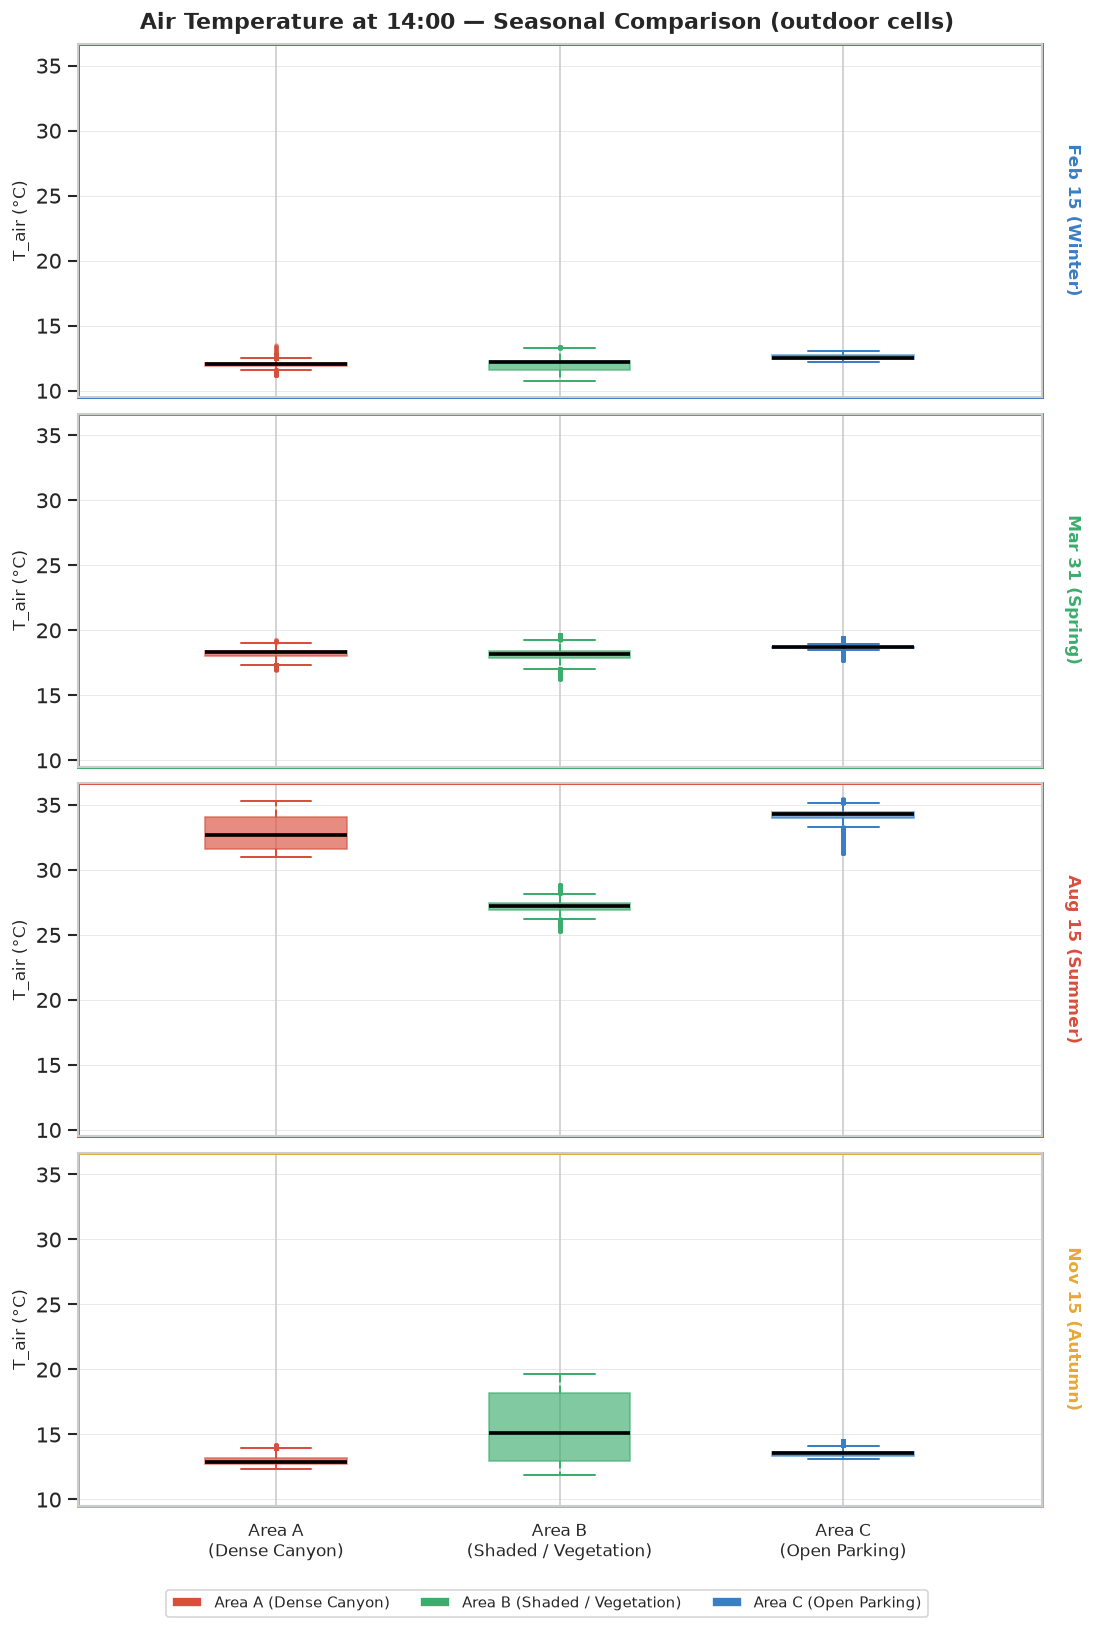

Saved A1


In [4]:
fig, axes = plt.subplots(len(DATE_ORDER), 1, figsize=(9, 13),
                         sharey=True, constrained_layout=True)
fig.suptitle(f'Air Temperature at {ATM_PEAK}:00 — Seasonal Comparison (outdoor cells)',
             fontsize=13, fontweight='bold')

for r, (ax, date) in enumerate(zip(axes, DATE_ORDER)):
    draw_peak_boxes(ax, atm, AIR_TEMP_COL, date, show_xlabel=(r == len(DATE_ORDER)-1))
    ax.set_ylabel('T_air (°C)', fontsize=10)
    add_season_label(ax, date)

area_patches = [mpatches.Patch(facecolor=AREA_COLORS[a], label=AREA_LABELS[a].replace('\n', ' '))
                for a in AREA_ORDER]
fig.legend(handles=area_patches, loc='upper center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=True)

fig.savefig(SAVE_DIR / 'A1_air_peak_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved A1')

## A2 — Air temperature: morning vs afternoon heating
Light box = 08:00 (morning), dark box = 14:00 (afternoon). Same area colour — darker = hotter time.

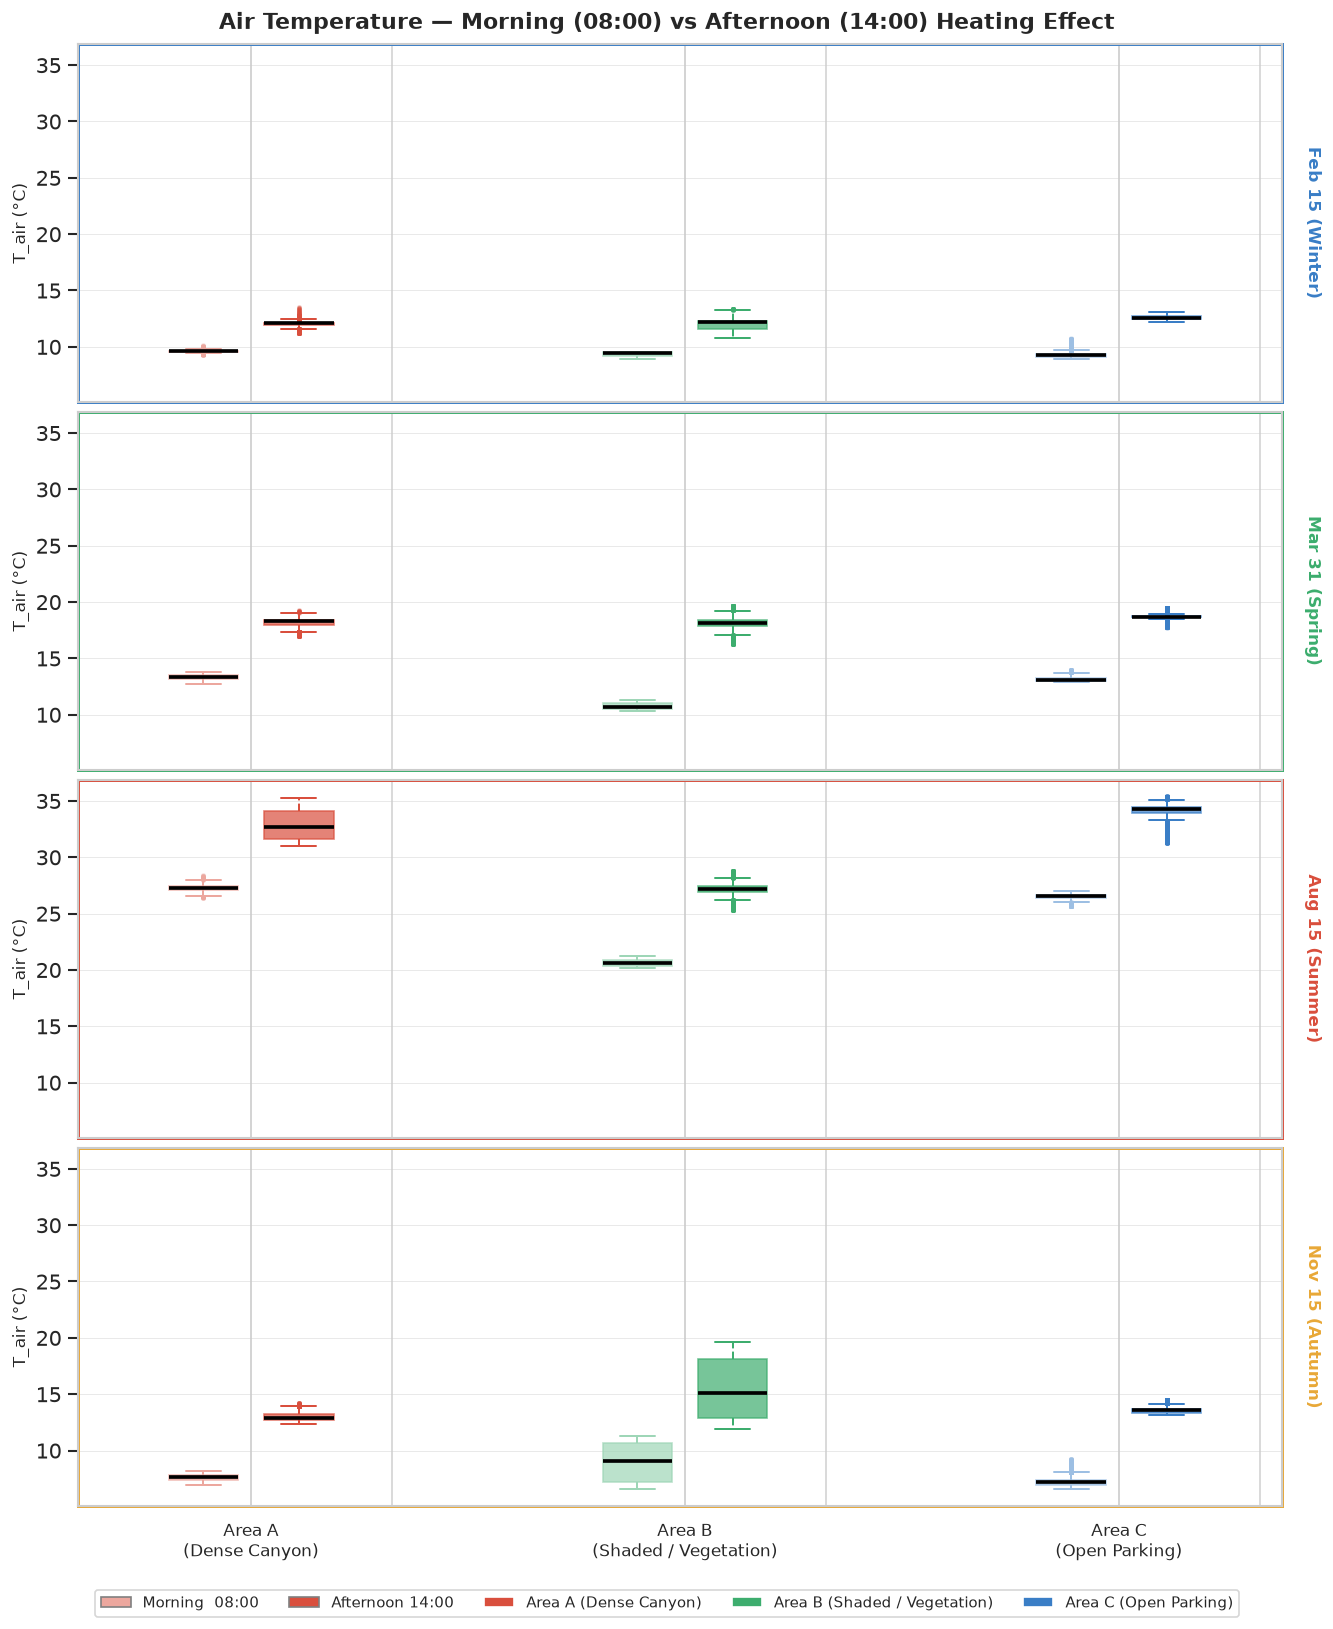

Saved A2


In [5]:
fig, axes = plt.subplots(len(DATE_ORDER), 1, figsize=(11, 13),
                         sharey=True, constrained_layout=True)
fig.suptitle('Air Temperature — Morning (08:00) vs Afternoon (14:00) Heating Effect',
             fontsize=13, fontweight='bold')

for r, (ax, date) in enumerate(zip(axes, DATE_ORDER)):
    draw_morning_vs_afternoon(ax, atm, AIR_TEMP_COL, date, show_xlabel=(r == len(DATE_ORDER)-1))
    ax.set_ylabel('T_air (°C)', fontsize=10)
    add_season_label(ax, date)

# Legend: light/dark patches for one area to illustrate time encoding
ref = AREA_COLORS[AREA_ORDER[0]]
time_patches = [
    mpatches.Patch(facecolor=lighten(ref, 0.5), edgecolor='grey', label='Morning  08:00'),
    mpatches.Patch(facecolor=ref,               edgecolor='grey', label='Afternoon 14:00'),
]
area_patches = [mpatches.Patch(facecolor=AREA_COLORS[a], label=AREA_LABELS[a].replace('\n', ' '))
                for a in AREA_ORDER]
fig.legend(handles=time_patches + area_patches,
           loc='upper center', ncol=5, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=True)

fig.savefig(SAVE_DIR / 'A2_air_morning_vs_afternoon.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved A2')

## A3 — Surface temperature at peak hour (13:00)

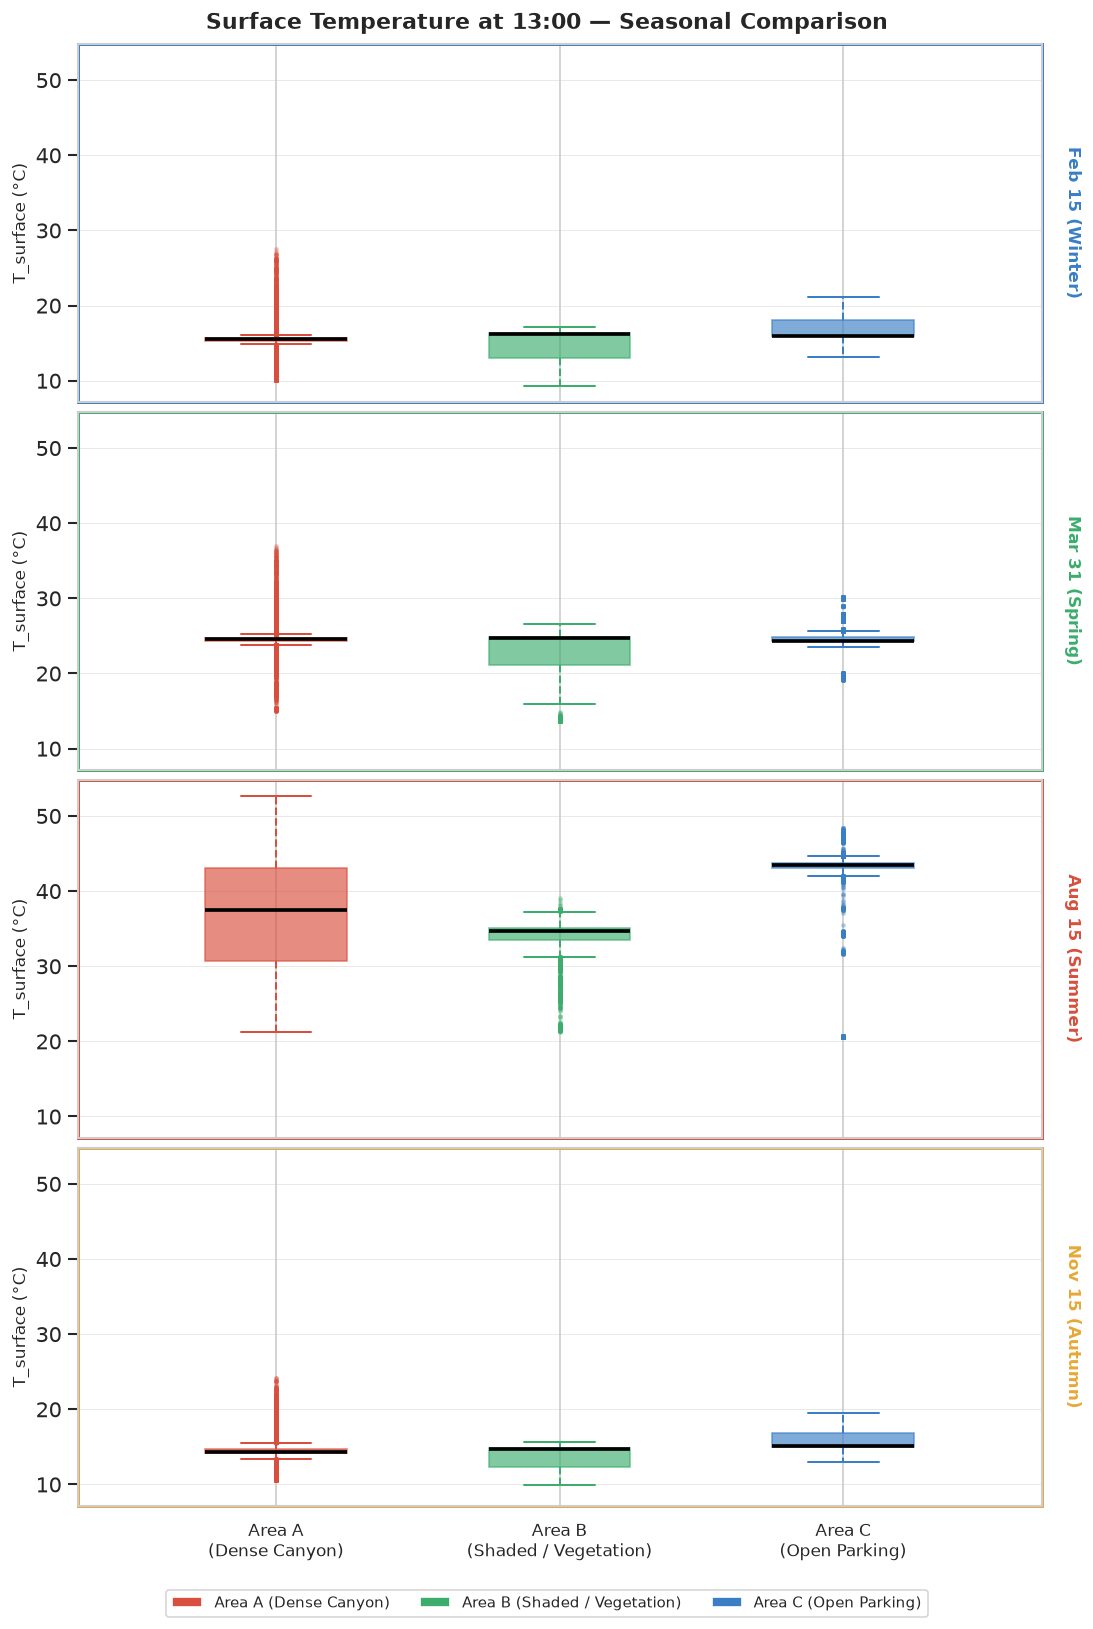

Saved A3


In [6]:
fig, axes = plt.subplots(len(DATE_ORDER), 1, figsize=(9, 13),
                         sharey=True, constrained_layout=True)
fig.suptitle(f'Surface Temperature at {SRF_PEAK}:00 — Seasonal Comparison',
             fontsize=13, fontweight='bold')

for r, (ax, date) in enumerate(zip(axes, DATE_ORDER)):
    draw_peak_boxes(ax, srf, SURF_TEMP_COL, date,
                    show_xlabel=(r == len(DATE_ORDER)-1), hour=SRF_PEAK)
    ax.set_ylabel('T_surface (°C)', fontsize=10)
    add_season_label(ax, date)

area_patches = [mpatches.Patch(facecolor=AREA_COLORS[a], label=AREA_LABELS[a].replace('\n', ' '))
                for a in AREA_ORDER]
fig.legend(handles=area_patches, loc='upper center', ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.01), frameon=True)

fig.savefig(SAVE_DIR / 'A3_surface_peak_by_season.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved A3')

## Summary statistics table

In [7]:
rows = []
for date in DATE_ORDER:
    for area in AREA_ORDER:
        for h in [MORNING, ATM_PEAK]:
            for label, df, col in [
                ('air',     atm, AIR_TEMP_COL),
                ('surface', srf, SURF_TEMP_COL),
            ]:
                sub = df[(df['area']==area)&(df['date']==date)&(df['hour']==h)][col].dropna()
                if len(sub) == 0: continue
                rows.append({
                    'Season': date, 'Area': area, 'Hour': f'{h:02d}h', 'Type': label,
                    'Median': round(float(sub.median()), 2),
                    'IQR':    round(float(sub.quantile(.75) - sub.quantile(.25)), 2),
                    'Min':    round(float(sub.min()), 2),
                    'Max':    round(float(sub.max()), 2),
                })

print(pd.DataFrame(rows).to_string(index=False))
print('\nAll done. Figures saved to:', SAVE_DIR)

Season       Area Hour    Type  Median  IQR   Min   Max
 15Feb Zefkseidos  08h     air    9.59 0.10  9.31 10.13
 15Feb Zefkseidos  08h surface    9.99 0.30  8.46 15.20
 15Feb Zefkseidos  14h     air   12.08 0.23 11.21 13.50
 15Feb Zefkseidos  14h surface   14.75 0.32  9.94 25.75
 15Feb     Shaded  08h     air    9.44 0.38  8.93  9.57
 15Feb     Shaded  08h surface    9.68 1.73  7.46  9.80
 15Feb     Shaded  14h     air   12.23 0.66 10.75 13.39
 15Feb     Shaded  14h surface   16.18 3.54  9.36 17.21
 15Feb Waterfront  08h     air    9.25 0.24  8.92 10.74
 15Feb Waterfront  08h surface    8.17 1.19  7.93 19.02
 15Feb Waterfront  14h     air   12.52 0.28 12.19 13.06
 15Feb Waterfront  14h surface   15.95 2.17 13.41 21.11
 31Mar Zefkseidos  08h     air   13.33 0.36 12.70 13.82
 31Mar Zefkseidos  08h surface   15.56 0.26 11.86 24.96
 31Mar Zefkseidos  14h     air   18.33 0.42 16.98 19.28
 31Mar Zefkseidos  14h surface   24.34 0.44 15.36 35.96
 31Mar     Shaded  08h     air   10.68 0.50 10.2

## A4 — Διαφάνεια: Θερμοκρασία αέρα + επιφάνειας (Ελληνικοί τίτλοι)
Δύο ξεχωριστές εικόνες — μία ανά διαφάνεια.

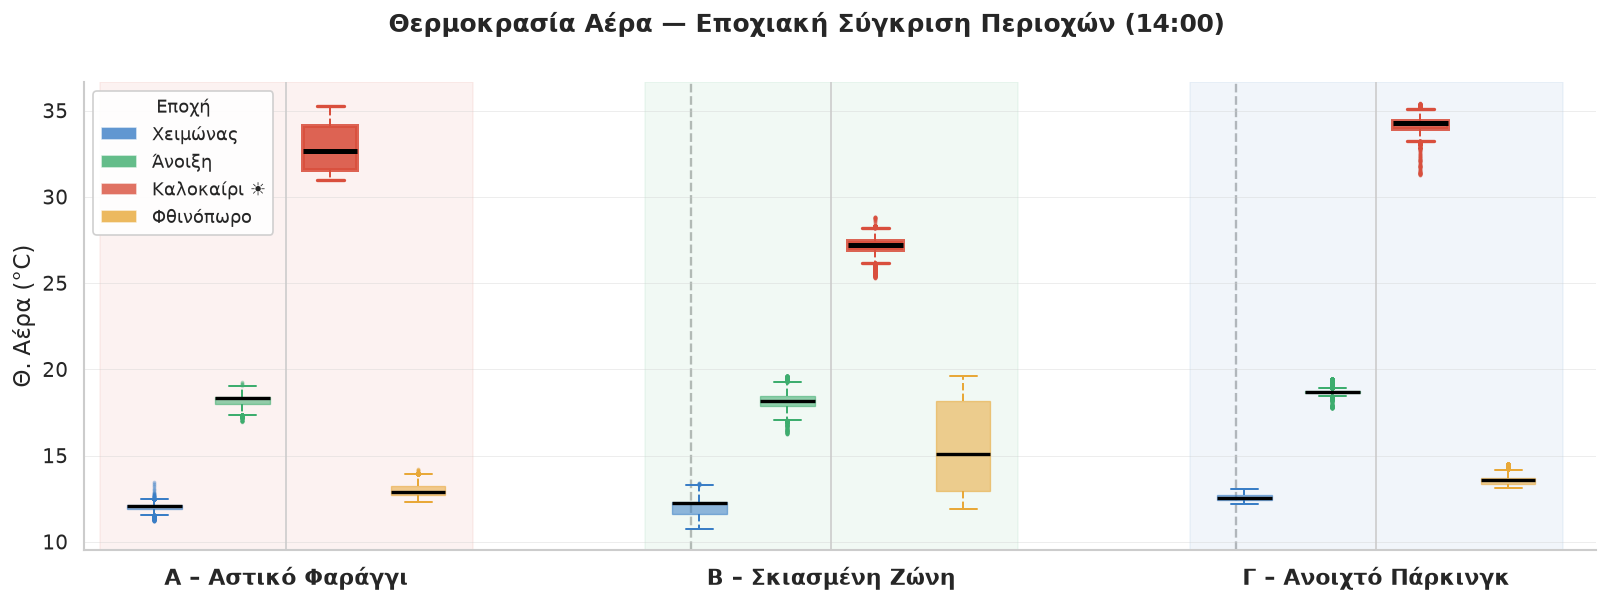

Saved A4_air_greek.png


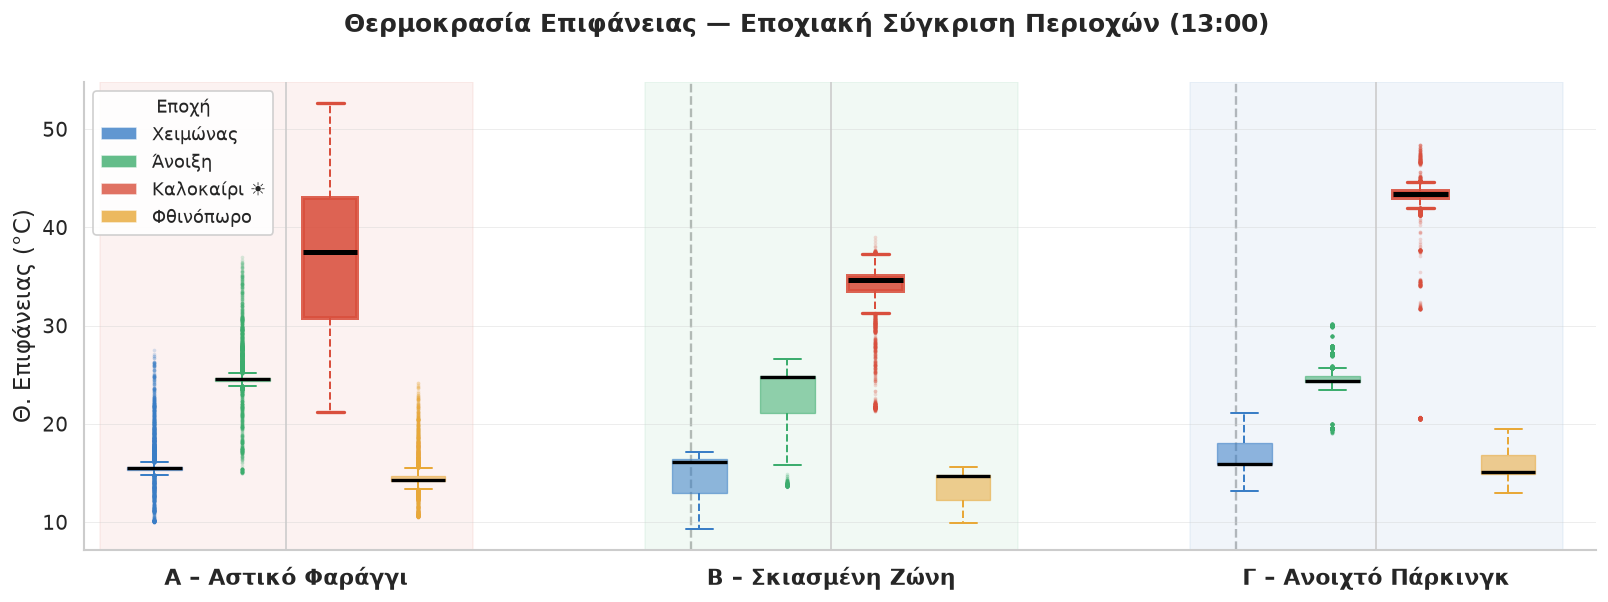

Saved A5_surface_greek.png


In [14]:
import matplotlib.patches as mpatches

GR_DATE = {
    '15Feb': 'Χειμώνας',
    '31Mar': 'Άνοιξη',
    '15Aug': 'Καλοκαίρι',
    '15Nov': 'Φθινόπωρο',
}
GR_AREA = {
    'Zefkseidos': 'Α – Αστικό Φαράγγι',
    'Shaded':     'Β – Σκιασμένη Ζώνη',
    'Waterfront': 'Γ – Ανοιχτό Πάρκινγκ',
}
AIR_H, SRF_H = 14, 13

# Layout: areas are outer groups, seasons are inner boxes
N_SEASONS = len(DATE_ORDER)   # 4
BOX_W     = 0.62
GRP_STEP  = N_SEASONS + 2.2   # gap between area groups

def area_season_positions(a_idx):
    """X positions of the 4 season boxes inside area group a_idx."""
    start = 1.0 + a_idx * GRP_STEP
    return [start + s for s in range(N_SEASONS)]

area_centres = [np.mean(area_season_positions(a)) for a in range(len(AREA_ORDER))]
x_max = max(area_season_positions(len(AREA_ORDER) - 1)) + 1.0


def make_slide_v2(df, col, hour, title, ylabel, fname):
    fig, ax = plt.subplots(figsize=(14, 6.5))
    fig.subplots_adjust(left=0.07, right=0.97, top=0.88, bottom=0.28)
    fig.suptitle(title, fontsize=15, fontweight='bold', y=0.97)

    ax.set_ylabel(ylabel, fontsize=14)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', lw=0.5, alpha=0.4)
    ax.tick_params(axis='y', labelsize=12)
    ax.tick_params(axis='x', which='both', length=0, pad=10)

    for a_idx, area in enumerate(AREA_ORDER):
        positions = area_season_positions(a_idx)
        area_clr  = AREA_COLORS[area]

        # Subtle column background per area — makes photo alignment obvious
        x0 = positions[0] - BOX_W
        x1 = positions[-1] + BOX_W
        ax.axvspan(x0, x1, alpha=0.07, color=area_clr, zorder=0)

        # Separator between area groups
        if a_idx < len(AREA_ORDER) - 1:
            ax.axvline(positions[-1] + GRP_STEP / 2,
                       color='#bbb', lw=1.4, ls='--', zorder=0)

        for pos, date in zip(positions, DATE_ORDER):
            sub = df[
                (df['area'] == area) &
                (df['date'] == date) &
                (df['hour'] == hour)
            ][col].dropna().values
            if not len(sub):
                continue

            is_summer = (date == '15Aug')
            s_clr  = DATE_COLORS[date]
            alpha  = 0.88 if is_summer else 0.55
            lw_med = 3.0  if is_summer else 2.0
            box_lw = 2.4  if is_summer else 0.8

            ax.boxplot(
                sub,
                positions=[pos],
                widths=BOX_W,
                patch_artist=True,
                medianprops=dict(color='black', linewidth=lw_med),
                whiskerprops=dict(linestyle='--', linewidth=1.2, color=s_clr),
                capprops=dict(linewidth=1.2 if not is_summer else 2.0, color=s_clr),
                flierprops=dict(marker='o', markersize=2.2, alpha=0.2,
                                markerfacecolor=s_clr, markeredgewidth=0),
                boxprops=dict(facecolor=s_clr, alpha=alpha,
                              color=s_clr, linewidth=box_lw),
            )

    # Area labels centred under each group
    ax.set_xticks(area_centres)
    ax.set_xticklabels([GR_AREA[a] for a in AREA_ORDER],
                       fontsize=13, fontweight='bold')
    ax.set_xlim(0.2, x_max)

    # Season legend
    season_patches = [
        mpatches.Patch(facecolor=DATE_COLORS[d], alpha=0.80,
                       label=GR_DATE[d] + (' ☀' if d == '15Aug' else ''))
        for d in DATE_ORDER
    ]
    ax.legend(handles=season_patches, fontsize=11, loc='upper left',
              frameon=True, framealpha=0.92, edgecolor='#ccc',
              title='Εποχή', title_fontsize=11)

    fig.savefig(SAVE_DIR / fname, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved', fname)


make_slide_v2(atm, AIR_TEMP_COL, AIR_H,
              'Θερμοκρασία Αέρα — Εποχιακή Σύγκριση Περιοχών (14:00)',
              'Θ. Αέρα (°C)', 'A4_air_greek.png')

make_slide_v2(srf, SURF_TEMP_COL, SRF_H,
              'Θερμοκρασία Επιφάνειας — Εποχιακή Σύγκριση Περιοχών (13:00)',
              'Θ. Επιφάνειας (°C)', 'A5_surface_greek.png')
